In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
df = pd.read_excel('../data/processed/processed_first_task.xlsx')
df = df.drop(columns = 'Unnamed: 0')
df = df.dropna()
df.head()

,symptoms,Angina range,depression,ECG range,WMSI stress,D WMSI,WMSI range,target,log_WMSI_stress,WMSI_stress_high
0,3,0,3,0,1.000,0.000,0,1.0,0.000000,0
1,3,0,3,0,1.125,0.000,0,1.0,0.117783,1
2,3,0,3,0,1.125,0.125,1,0.0,0.117783,1
3,1,1,3,0,1.000,-0.190,1,1.0,0.000000,0
4,3,0,3,0,1.120,0.120,1,0.0,0.113329,0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, recall_score, RocCurveDisplay, roc_auc_score, make_scorer, precision_recall_curve, precision_score, f1_score, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline

features_2d = ['WMSI range', 'Angina range', 'ECG range']


X_small = df[features_2d].copy()
y_work = df['target'].copy()

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=10))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def specificity_score(y_true, y_pred):
    """
    Рассчитывает специфичность (True Negative Rate)
    Specificity = TN / (TN + FP)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

specificity_scorer = make_scorer(specificity_score)

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": specificity_scorer, 
    'auc-roc' : make_scorer(roc_auc_score, needs_proba=True)
}

cv_results = cross_validate(
    model_log,
    X_small,
    y_work,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],
    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],
    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],
    "Specificity mean": [cv_results["test_specificity"].mean()],  
    "Specificity std": [cv_results["test_specificity"].std()],   
    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],
    "ROC-AUC mean": [cv_results["test_auc-roc"].mean()],
    "ROC-AUC std": [cv_results["test_auc-roc"].std()],
})

print(metrics_df)

model_log.fit(X_small, y_work)

coef = model_log.named_steps["clf"].coef_.ravel()

coef_df = (
    pd.Series(coef, index=features_2d)
    .sort_values(key=np.abs, ascending=False)
)

coef_df

    F1 mean    F1 std  Precision mean  Precision std  Recall mean  Recall std  \
0  0.531205  0.059846        0.475406       0.042891     0.607407    0.100342   

   Specificity mean  Specificity std  Accuracy mean  Accuracy std  \
0          0.758719         0.034222        0.71903       0.02798   

   ROC-AUC mean  ROC-AUC std  
0      0.693877     0.062686  


c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


WMSI range      0.727015
ECG range       0.092019
Angina range    0.025166
dtype: float64

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import optuna

features = ['WMSI range', 'Angina range', 'ECG range']

X = df[features].copy()
y = df['target'].copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'penalty': trial.suggest_categorical(
            'penalty',
            ['l1', 'l2']
        ),
        'solver': trial.suggest_categorical(
            'solver',
            ['liblinear', 'saga']
        ),
        'max_iter': trial.suggest_int(
            'max_iter',
            300,
            3000
        )
    }

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            random_state=42,
            **params
        ))
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()


optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=False
)
print("=" * 50)
print("BEST PARAMS")
print("=" * 50)

print(study.best_params)

print("\nBEST ROC-AUC:")
print(round(study.best_value, 4))
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        **study.best_params
    ))
])

best_model.fit(X, y)
coef = best_model.named_steps['clf'].coef_.ravel()

coef_df = (
    pd.Series(coef, index=features)
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

print("\n" + "=" * 50)
print("FEATURE COEFFICIENTS")
print("=" * 50)

print(coef_df)

BEST PARAMS
{'C': 0.26349013654179704, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 1873}

BEST ROC-AUC:
0.6952

FEATURE COEFFICIENTS
WMSI range      0.709102
ECG range       0.067541
Angina range    0.000855
dtype: float64


In [91]:
cv_results = cross_validate(
    best_model,
    X,
    y,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],
    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],
    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],
    "Specificity mean": [cv_results["test_specificity"].mean()],  
    "Specificity std": [cv_results["test_specificity"].std()],   
    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],
    "ROC-AUC mean": [cv_results["test_roc_auc"].mean()],
    "ROC-AUC std": [cv_results["test_roc_auc"].std()],
})

print(metrics_df)

    F1 mean    F1 std  Precision mean  Precision std  Recall mean  Recall std  \
0  0.531205  0.059846        0.475406       0.042891     0.607407    0.100342   

   Specificity mean  Specificity std  Accuracy mean  Accuracy std  \
0          0.758719         0.034222        0.71903       0.02798   

   ROC-AUC mean  ROC-AUC std  
0      0.695155     0.063242  


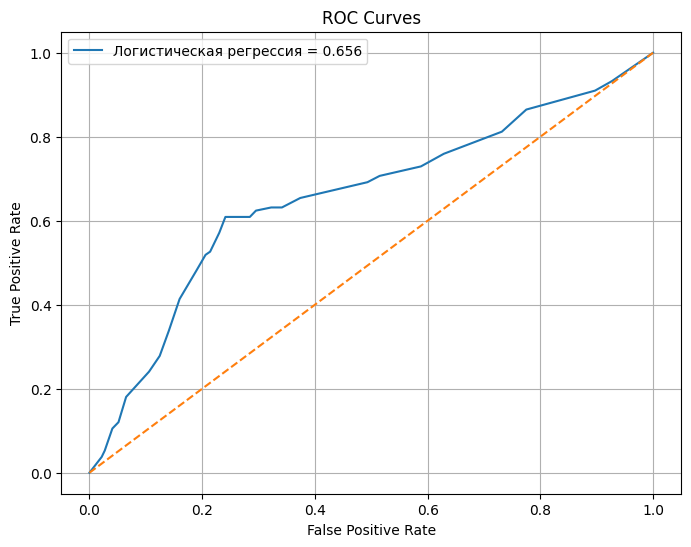

In [87]:
y_proba_log = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_work, y_proba_log)
auc_log = roc_auc_score(y_work, y_proba_log)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Логистическая регрессия = {auc_log:.3f}'
)


plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

plt.legend()
plt.grid(True)

plt.show()


In [80]:
from catboost import CatBoostClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    make_scorer
)

features = ['WMSI range', 'Angina range', 'ECG range']

X = df[features].copy()
y = df['target'].copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

specificity_scorer = make_scorer(specificity_score)

model_cat = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": specificity_scorer,
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model_cat,
    X,
    y,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],

    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],

    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],

    "Specificity mean": [cv_results["test_specificity"].mean()],
    "Specificity std": [cv_results["test_specificity"].std()],

    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],

    "ROC-AUC mean": [cv_results["test_roc_auc"].mean()],
    "ROC-AUC std": [cv_results["test_roc_auc"].std()],
})

print(metrics_df)
model_cat.fit(X, y)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": model_cat.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\nFeature importance:")
print(importance_df)

y_proba = model_cat.predict_proba(X)[:, 1]

auc = roc_auc_score(y, y_proba)

print(f"\nROC-AUC on full data: {auc:.4f}")

    F1 mean    F1 std  Precision mean  Precision std  Recall mean  Recall std  \
0  0.531205  0.059846        0.475406       0.042891     0.607407    0.100342   

   Specificity mean  Specificity std  Accuracy mean  Accuracy std  \
0          0.758719         0.034222        0.71903       0.02798   

   ROC-AUC mean  ROC-AUC std  
0      0.658007     0.053852  

Feature importance:
        feature  importance
0    WMSI range   93.704483
2     ECG range    3.709802
1  Angina range    2.585714

ROC-AUC on full data: 0.7010


In [82]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score, StratifiedKFold


def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 2, 100),
        'depth': trial.suggest_int('depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 1e-5, 10, log=True),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False, 
        'auto_class_weights': 'Balanced'
    }
    
    model = CatBoostClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(
    direction='maximize',  
    sampler=TPESampler(seed=42),
    study_name='catboost_optimization'
)

study.optimize(
    objective, 
    n_trials=300, 
    n_jobs=1,
)

print("ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"{key}: {value}")

print(f"\nЛучшее значение метрики: {study.best_value:.4f}")


final_params = best_params.copy()
final_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 0,
    'auto_class_weights': 'Balanced'
})

print("Параметры модели:")
for key, value in final_params.items():
    print(f"  {key}: {value}")

final_model = CatBoostClassifier(**final_params)
final_model.fit(X, y)

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": make_scorer(specificity_score),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    final_model,
    X,
    y,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

# Результаты
metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],
    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],
    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],
    "Specificity mean": [cv_results["test_specificity"].mean()],
    "Specificity std": [cv_results["test_specificity"].std()],
    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],
    "ROC-AUC mean": [cv_results["test_roc_auc"].mean()],
    "ROC-AUC std": [cv_results["test_roc_auc"].std()],
})

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ (CV):")
print("="*50)
print(metrics_df)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": final_model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

print("\n" + "="*50)
print("FEATURE IMPORTANCE:")
print("="*50)
print(importance_df)


y_proba = final_model.predict_proba(X)[:, 1]
auc = roc_auc_score(y, y_proba)
print(f"\nROC-AUC on full data: {auc:.4f}")

ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:
iterations: 20
depth: 6
learning_rate: 0.13962563737015762
l2_leaf_reg: 4.33504539277513
border_count: 232
bagging_temperature: 0.5978999788110851
random_strength: 3.398172415010594

Лучшее значение метрики: 0.6832
Параметры модели:
  iterations: 20
  depth: 6
  learning_rate: 0.13962563737015762
  l2_leaf_reg: 4.33504539277513
  border_count: 232
  bagging_temperature: 0.5978999788110851
  random_strength: 3.398172415010594
  loss_function: Logloss
  eval_metric: AUC
  random_seed: 42
  verbose: 0
  auto_class_weights: Balanced

РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ (CV):
    F1 mean    F1 std  Precision mean  Precision std  Recall mean  Recall std  \
0  0.531205  0.059846        0.475406       0.042891     0.607407    0.100342   

   Specificity mean  Specificity std  Accuracy mean  Accuracy std  \
0          0.758719         0.034222        0.71903       0.02798   

   ROC-AUC mean  ROC-AUC std  
0      0.683244     0.061434  

FEATURE IMPORTANCE:
        feature  impor

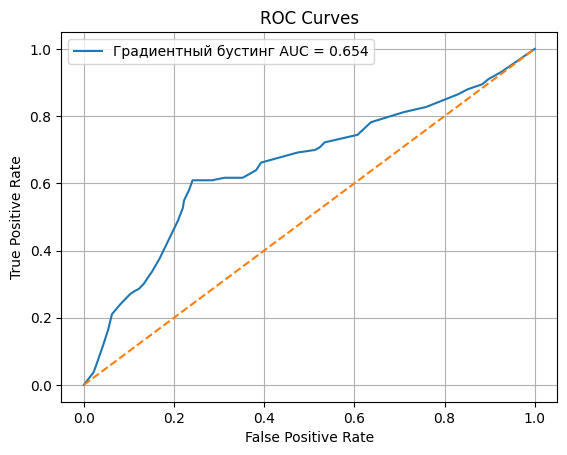

In [83]:
y_proba_cat = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]
fpr_cat, tpr_cat, _ = roc_curve(y, y_proba_cat)
auc_cat = roc_auc_score(y, y_proba_cat)
plt.plot(
    fpr_cat,
    tpr_cat,
    label=f'Градиентный бустинг AUC = {auc_cat:.3f}'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
from scipy import stats


def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r] = compute_midrank(positive_examples[r])
        ty[r] = compute_midrank(negative_examples[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n

    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    pvalue = 2 * (1 - stats.norm.cdf(z))
    return pvalue


def delong_roc_test(y_true, pred1, pred2):
    order = np.argsort(-y_true)

    y_true_sorted = y_true[order]

    preds = np.vstack((pred1, pred2))[:, order]

    label_1_count = int(np.sum(y_true))

    aucs, delongcov = fast_delong(preds, label_1_count)

    pvalue = calc_pvalue(aucs, delongcov)

    return aucs, pvalue[0][0]

In [88]:
aucs, p_value = delong_roc_test(
    y.values,
    y_proba_log,
    y_proba_cat
)

print(f"Логистическая регрессия AUC: {aucs[0]:.4f}")
print(f"Градиентный бустинг AUC: {aucs[1]:.4f}")
print(f"DeLong p-value: {p_value:.6f}")

Логистическая регрессия AUC: 0.6564
Градиентный бустинг AUC: 0.6539
DeLong p-value: 0.792403
